# Imports

In [1]:
import os
import sys

In [2]:
current_dir =  os.getcwd()
# replace this following line in the path your frank2d files are.
parent_dir = os.path.abspath(os.path.join(current_dir, os.pardir))
sys.path.append(parent_dir)

In [3]:
parent_dir

'/localhome/home/zgdz996/frank2d'

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import time

In [5]:
# frank2d
from frank2d import Frank2D
from frank2d.geometry import Geometry
from frank2d.plot import Plot
from frank2d.posterior_optimization import *
from frank2d.constants import rad_to_arcsec, deg_to_rad
from frank2d.posterior_optimization import MAPEstimator

In [6]:
dir = "./../../data/"
data_file = dir + "SimulatedBlob.txt"
inc = 0
pa = 0
dra = 0
ddec = 0
rout = 1

# Load data
file = np.loadtxt(data_file, unpack=True)
u, v, Re, Im, Weights = file
Vis = Re + 1j * Im
uvtable = {'u': u, 'v': v, 'vis': Vis, 'weights': Weights }

geom = Geometry(inc, pa, dra, ddec)

## F2D

In [7]:
Rmax = 2*rout
Qmax = max(np.hypot(u,v))

import math

N = math.floor(5* Rmax/rad_to_arcsec * Qmax)

In [8]:
best_N50 = {'m': -2.1725772998867527, 'c': 2227336539.713243, 'l': 70600.20854903864}

In [9]:
l = [1e4, 2e4, 4e4, 5e4, best_N50['l'], 8e4, 9e4]

### Wendland

In [10]:
frank2d_wend = Frank2D(N, Rmax)

In [11]:
frank2d_wend.process_vis(uvtable)

===>  Setting gridded data...


In [12]:
frank2d_wend.set_kernel(kernel_type = "wend", kernel_params = best_N50)
frank2d_wend.set_x0(None)

===>  Setting GP Kernel wend...
        + Kernel parameters:  {'m': -2.1725772998867527, 'c': 2227336539.713243, 'l': 70600.20854903864}


In [13]:
frank2d_wend.set_fit_method()

In [14]:
WEND = frank2d_wend._kernel.sparse_matrix()

In [15]:
tick_positions_y = [0, 700,1000,  3995]
tick_labels_y = [
    r"$(u, v)_{0}$",
    r"$(u, v)_{N}$",
    r"$(u, v)_{N+1}$",
    r"$(u, v)_{N^{2}}$",
]

tick_positions_x = [0, 700,  3995]
tick_labels_x = [
    r"$(u, v)_{0}$",
    r"$(u, v)_{N}$",
    r"$(u, v)_{N^{2}}$",
]

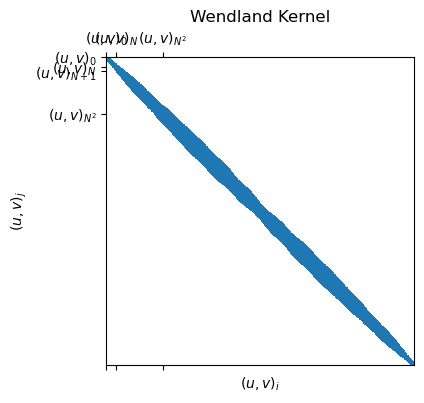

In [16]:
plt.figure(figsize=(4, 4))
plt.spy(WEND, markersize=1)
plt.title("Wendland Kernel")
plt.xlabel("Índice de Columna")
plt.ylabel("Índice de Fila")
plt.xlabel(r'$(u, v)_i$')
plt.ylabel(r'$(u, v)_j$')
plt.xticks(tick_positions_x, tick_labels_x)
plt.yticks(tick_positions_y, tick_labels_y)
#plt.xlim(0, 4000)
#plt.ylim(0, 4000)
plt.show()

In [17]:
times_wend = []

In [18]:
times_wend = []

In [19]:
frank2d_objects_wend = []

In [20]:
for i in l:
    start_time = time.time()
    params = {'m': best_N50['m'], 'c': best_N50['c'], 'l': i}
    frank2d_wend = Frank2D(N, Rmax)
    frank2d_wend.fit(uvtable, kernel_type='wend', kernel_params = params, rtol = 1e-10)
    frank2d_objects_wend.append(frank2d_wend)
    end_time = time.time()
    times_wend.append(end_time - start_time)

===>  Setting gridded data...
===>  Setting GP Kernel wend...
        + Kernel parameters:  {'m': -2.1725772998867527, 'c': 2227336539.713243, 'l': 10000.0}
===>  Creating sparse linear system...
        +  Kernel = 0.01  min |  0.42 seconds
        +  Building system = 0.01  min |  0.42 seconds
===>  Solving linear system...


         + Fitting with BiCGStab...:   0%|          | 0/50000 [00:00<?, ? iterations/s]

            +  BiCGStab = 0.00  min |  0.01 seconds
{'CGM_converged': True,
 'Fit_correctly': True,
 'convergence_by': 'norm of s',
 'final_tol': 0.10082246852331034,
 'iterations': 0,
 'maxiter': 50000,
 'preconditioner_method': 'jacobi',
 'rtol': 1e-10}
Building full visibility model...


     + Setting kernel..
--> time building S_12_T = 0.05  min |  2.73 seconds
--> times building full visibility model = 0.05  min |  2.74 seconds
===>  Setting gridded data...
===>  Setting GP Kernel wend...
        + Kernel parameters:  {'m': -2.1725772998867527, 'c': 2227336539.713243, 'l': 20000.0}
===>  Creating sparse linear system...
        +  Kernel = 0.01  min |  0.49 seconds
        +  Building system = 0.01  min |  0.50 seconds
===>  Solving linear system...


         + Fitting with BiCGStab...:   0%|          | 5/50000 [00:00<02:17, 363.07 iterations/s]

...

            +  BiCGStab = 0.04  min |  2.21 seconds
{'CGM_converged': True,
 'Fit_correctly': True,
 'convergence_by': 'norm of s',
 'final_tol': 0.10082246852331034,
 'iterations': 205,
 'maxiter': 50000,
 'preconditioner_method': 'jacobi',
 'rtol': 1e-10}
Building full visibility model...
     + Setting kernel..
--> time building S_12_T = 0.05  min |  3.18 seconds
--> times building full visibility model = 0.05  min |  3.19 seconds
===>  Setting gridded data...
===>  Setting GP Kernel wend...
        + Kernel parameters:  {'m': -2.1725772998867527, 'c': 2227336539.713243, 'l': 80000.0}
===>  Creating sparse linear system...
        +  Kernel = 0.02  min |  1.07 seconds
        +  Building system = 0.02  min |  1.10 seconds
===>  Solving linear system...


         + Fitting with BiCGStab...:   1%|          | 257/50000 [00:03<11:07, 74.48 iterations/s]


            +  BiCGStab = 0.06  min |  3.45 seconds
{'CGM_converged': True,
 'Fit_correctly': True,
 'convergence_by': 'norm of s',
 'final_tol': 0.10082246852331034,
 'iterations': 257,
 'maxiter': 50000,
 'preconditioner_method': 'jacobi',
 'rtol': 1e-10}
Building full visibility model...
     + Setting kernel..
--> time building S_12_T = 0.05  min |  3.19 seconds
--> times building full visibility model = 0.05  min |  3.20 seconds
===>  Setting gridded data...
===>  Setting GP Kernel wend...
        + Kernel parameters:  {'m': -2.1725772998867527, 'c': 2227336539.713243, 'l': 90000.0}
===>  Creating sparse linear system...
        +  Kernel = 0.02  min |  1.25 seconds
        +  Building system = 0.02  min |  1.28 seconds
===>  Solving linear system...


         + Fitting with BiCGStab...:   1%|          | 560/50000 [00:09<13:40, 60.26 iterations/s]


            +  BiCGStab = 0.15  min |  9.30 seconds
{'CGM_converged': True,
 'Fit_correctly': True,
 'convergence_by': 'norm of s',
 'final_tol': 0.10082246852331034,
 'iterations': 560,
 'maxiter': 50000,
 'preconditioner_method': 'jacobi',
 'rtol': 1e-10}
Building full visibility model...
     + Setting kernel..
--> time building S_12_T = 0.06  min |  3.69 seconds
--> times building full visibility model = 0.06  min |  3.71 seconds


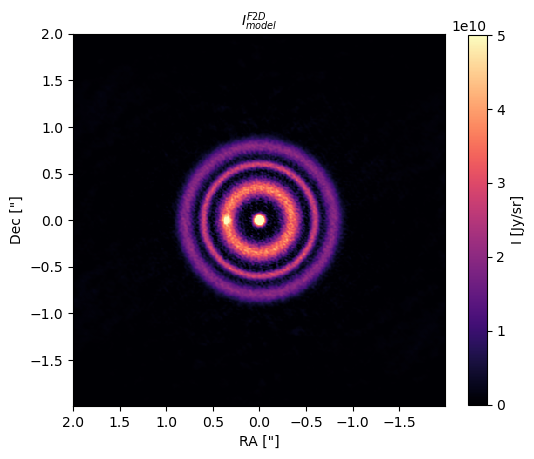

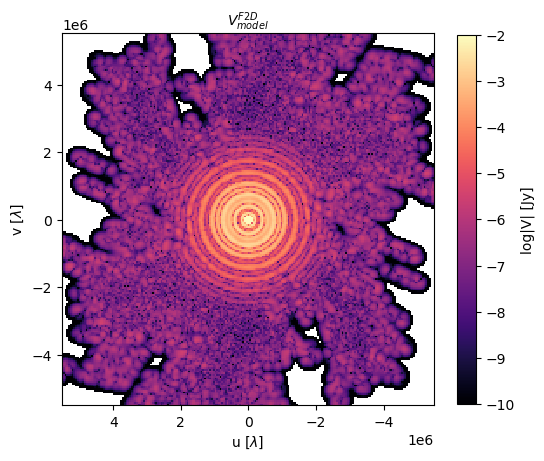

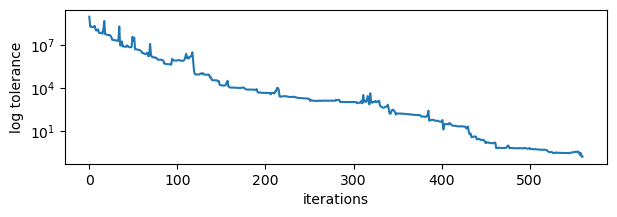

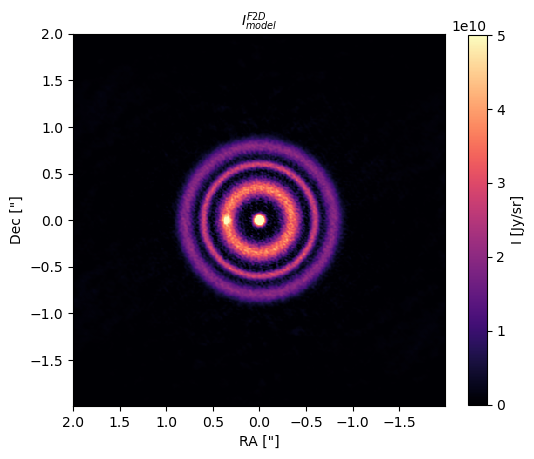

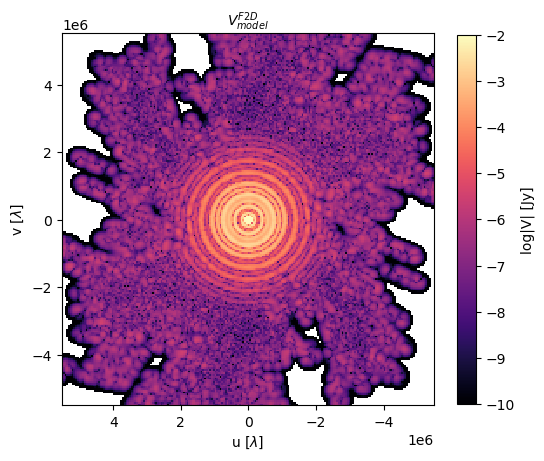

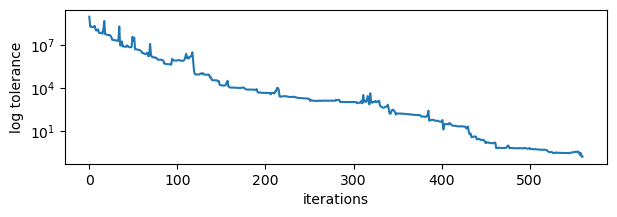

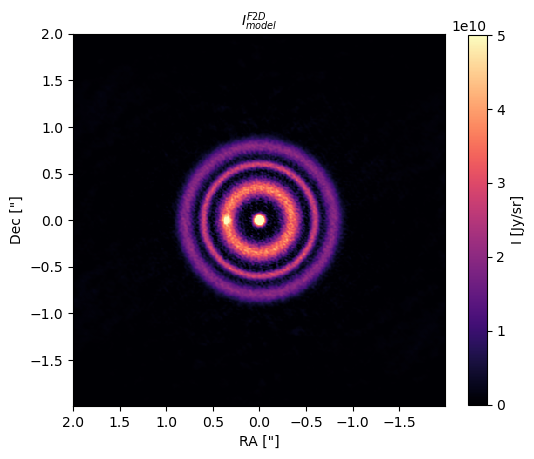

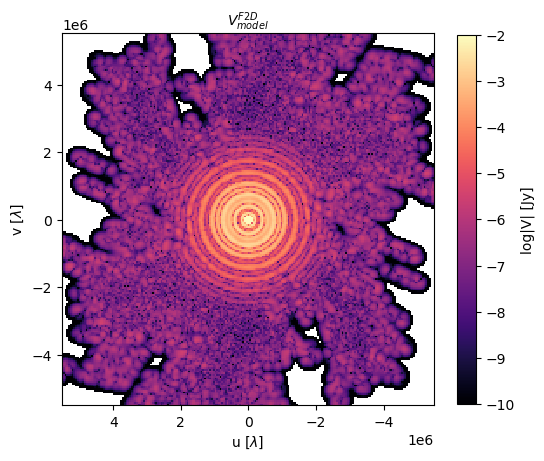

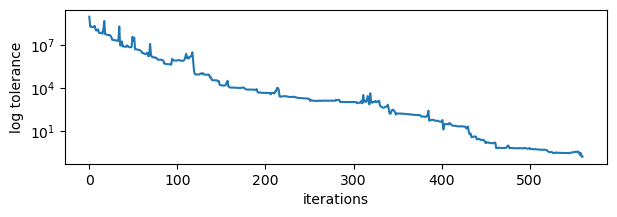

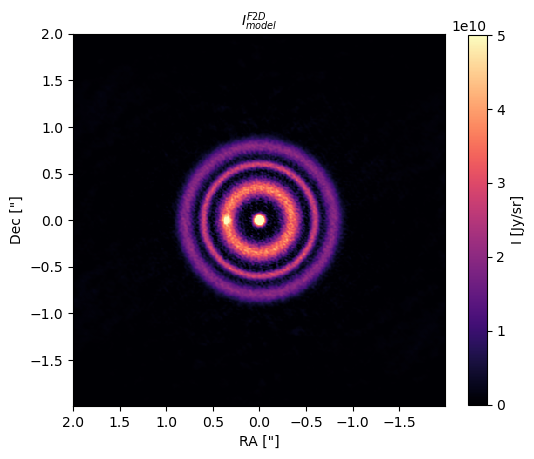

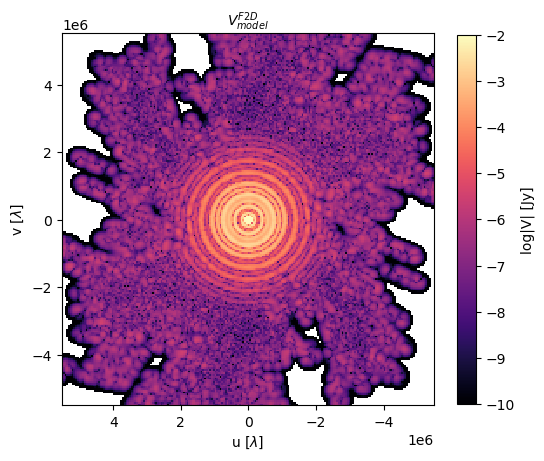

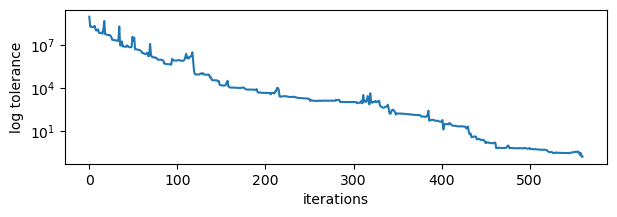

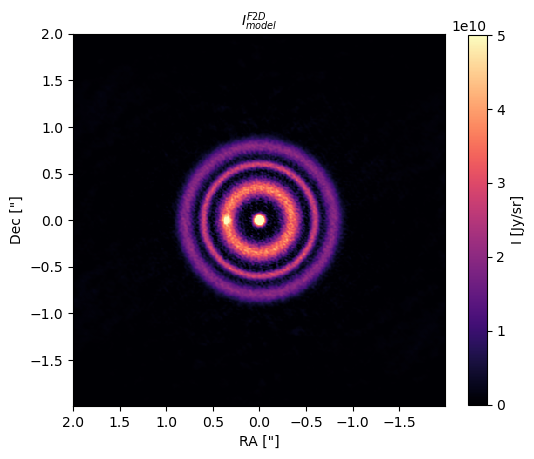

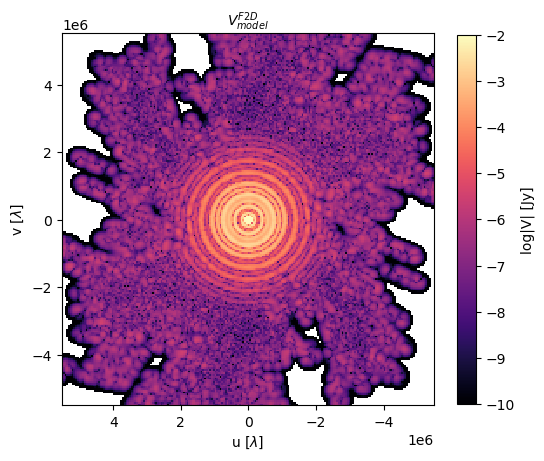

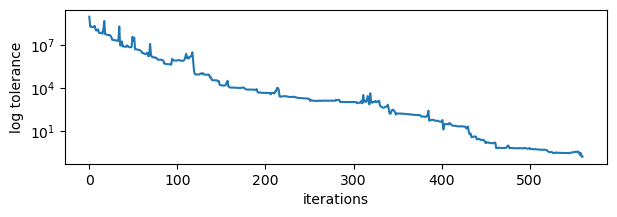

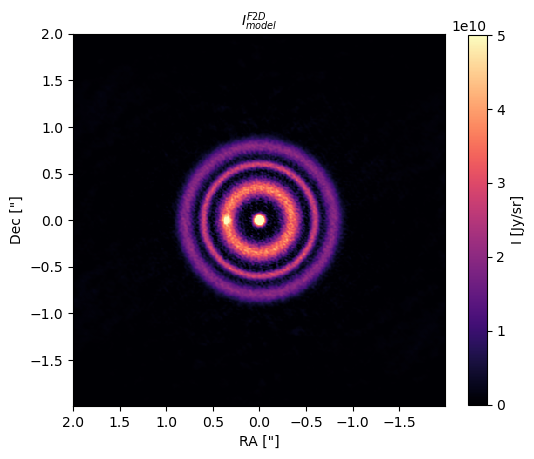

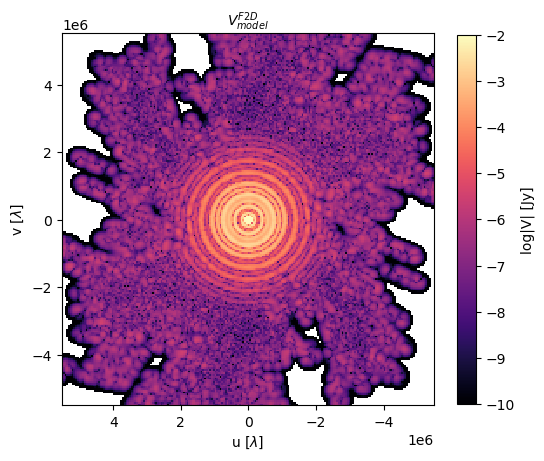

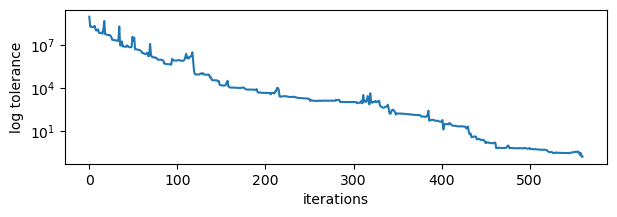

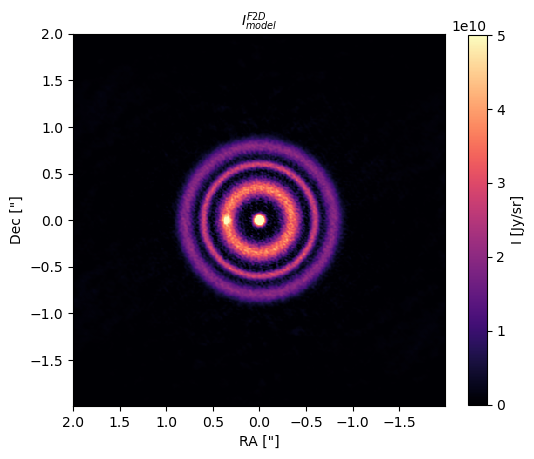

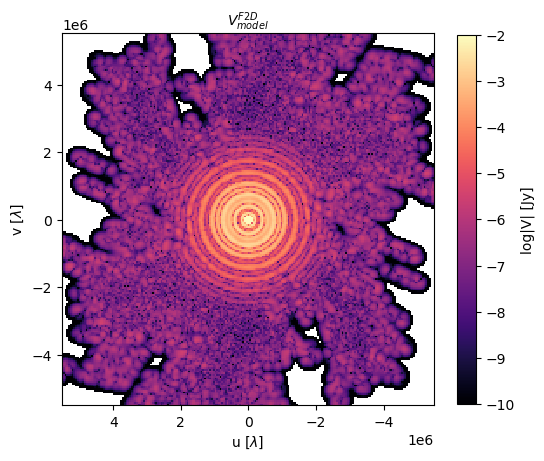

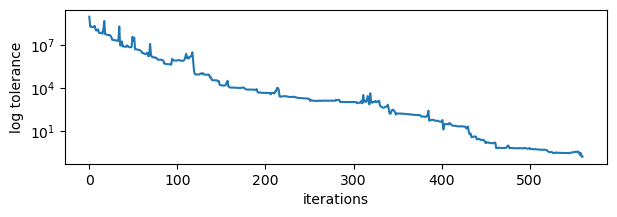

In [21]:
for i in l:
    Plot_wend = Plot(frank2d_wend, geom)
    Plot_wend.intensity(vmax=5e10, gamma = 1, zoom = 1, title = r'$I_{model}^{F2D}$')
    Plot_wend.visibility(fig_size = 6, zoom=2)
    Plot_wend.cg_tolerance()

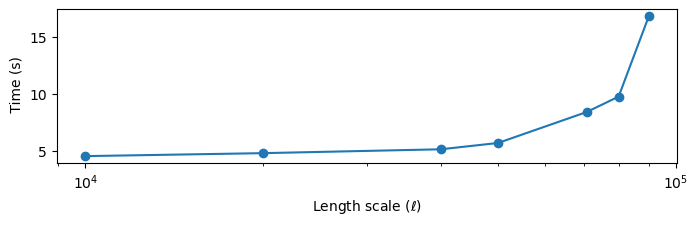

In [45]:
# plot times
plt.figure(figsize=(8,2))
plt.plot(l, times_wend, marker='o')
plt.xscale('log')
plt.xlabel(r'Length scale ($\ell$)')
plt.ylabel(' Time (s)')
plt.show()

#### SE Kernel

In [46]:
frank2d_se = Frank2D(N, Rmax)

In [47]:
frank2d_se.process_vis(uvtable)

===>  Setting gridded data...


In [48]:
frank2d_se.set_kernel(kernel_type = "sqexp", kernel_params = best_N50)
frank2d_se.set_x0(None)

===>  Setting GP Kernel sqexp...
        + Kernel parameters:  {'m': -2.1725772998867527, 'c': 2227336539.713243, 'l': 70600.20854903864}


In [49]:
frank2d_se.set_fit_method()

In [50]:
SE = frank2d_se._kernel.sparse_matrix()

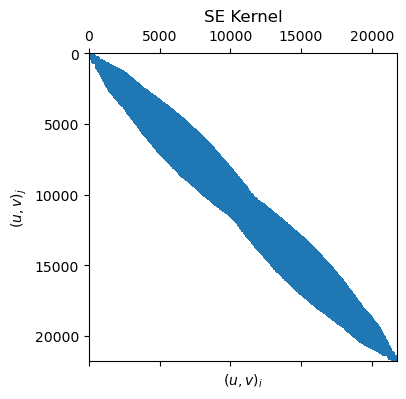

In [51]:
plt.figure(figsize=(4, 4))
plt.spy(SE, markersize=1)
plt.title("SE Kernel")
plt.xlabel(r'$(u, v)_i$')
plt.ylabel(r'$(u, v)_j$')
#plt.xlim(0, 4000)
#plt.ylim(0, 4000)
plt.show()

In [52]:
frank2d_objects_se = []
times_se = []

In [53]:
l

[10000.0, 20000.0, 40000.0, 50000.0, 70600.20854903864, 80000.0, 90000.0]

In [54]:
for i in l:
    if i > 7.9e4:
        pass
    else:
        start_time = time.time()
        params = {'m': best_N50['m'], 'c': best_N50['c'], 'l': i}
        frank2d_se = Frank2D(N, Rmax)
        frank2d_se.fit(
                        data = uvtable,
                        kernel_params = params , rtol = 1e-10, 
                        kernel_type = 'sqexp'
                    )
        frank2d_objects_se.append(frank2d_se)
        end_time = time.time()
        times_se.append(end_time - start_time)
    

===>  Setting gridded data...
===>  Setting GP Kernel sqexp...
        + Kernel parameters:  {'m': -2.1725772998867527, 'c': 2227336539.713243, 'l': 10000.0}
===>  Creating sparse linear system...
        +  Kernel = 0.01  min |  0.46 seconds
        +  Building system = 0.01  min |  0.47 seconds
===>  Solving linear system...


         + Fitting with BiCGStab...:   0%|          | 1/50000 [00:00<03:45, 221.84 iterations/s]

            +  BiCGStab = 0.00  min |  0.01 seconds
{'CGM_converged': True,
 'Fit_correctly': True,
 'convergence_by': 'norm of r',
 'final_tol': 0.10082246852331034,
 'iterations': 1,
 'maxiter': 50000,
 'preconditioner_method': 'jacobi',
 'rtol': 1e-10}
Building full visibility model...


     + Setting kernel..
--> time building S_12_T = 0.01  min |  0.52 seconds
--> times building full visibility model = 0.01  min |  0.53 seconds
===>  Setting gridded data...
===>  Setting GP Kernel sqexp...
        + Kernel parameters:  {'m': -2.1725772998867527, 'c': 2227336539.713243, 'l': 20000.0}
===>  Creating sparse linear system...
        +  Kernel = 0.02  min |  0.91 seconds
        +  Building system = 0.02  min |  0.93 seconds
===>  Solving linear system...


         + Fitting with BiCGStab...:   0%|          | 4/50000 [00:00<12:27, 66.88 iterations/s]

...

            +  BiCGStab = 0.03  min |  1.83 seconds
{'CGM_converged': True,
 'Fit_correctly': True,
 'convergence_by': 'norm of s',
 'final_tol': 0.10082246852331034,
 'iterations': 61,
 'maxiter': 50000,
 'preconditioner_method': 'jacobi',
 'rtol': 1e-10}
Building full visibility model...
     + Setting kernel..
--> time building S_12_T = 0.03  min |  1.50 seconds
--> times building full visibility model = 0.03  min |  1.53 seconds
===>  Setting gridded data...
===>  Setting GP Kernel sqexp...
        + Kernel parameters:  {'m': -2.1725772998867527, 'c': 2227336539.713243, 'l': 50000.0}
===>  Creating sparse linear system...
        +  Kernel = 0.04  min |  2.51 seconds
        +  Building system = 0.04  min |  2.62 seconds
===>  Solving linear system...


         + Fitting with BiCGStab...:   1%|▏         | 705/50000 [00:37<43:13, 19.00 iterations/s]


            +  BiCGStab = 0.62  min |  37.10 seconds
{'CGM_converged': True,
 'Fit_correctly': True,
 'convergence_by': 'norm of s',
 'final_tol': 0.10082246852331034,
 'iterations': 705,
 'maxiter': 50000,
 'preconditioner_method': 'jacobi',
 'rtol': 1e-10}
Building full visibility model...
     + Setting kernel..
--> time building S_12_T = 0.04  min |  2.52 seconds
--> times building full visibility model = 0.04  min |  2.57 seconds
===>  Setting gridded data...
===>  Setting GP Kernel sqexp...
        + Kernel parameters:  {'m': -2.1725772998867527, 'c': 2227336539.713243, 'l': 70600.20854903864}
===>  Creating sparse linear system...
        +  Kernel = 0.09  min |  5.39 seconds
        +  Building system = 0.09  min |  5.64 seconds
===>  Solving linear system...


         + Fitting with BiCGStab...:  33%|███▎      | 16298/50000 [33:56<1:10:11,  8.00 iterations/s]


KeyboardInterrupt: 

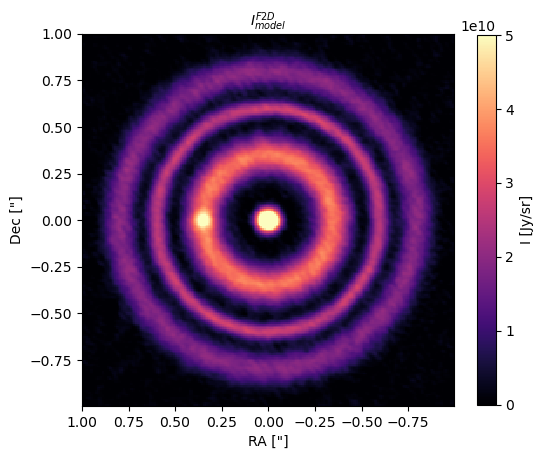

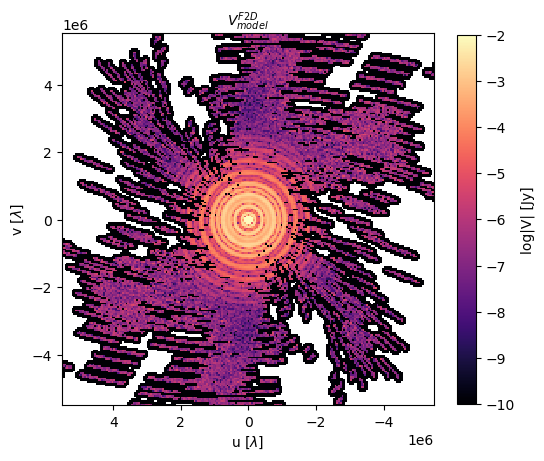

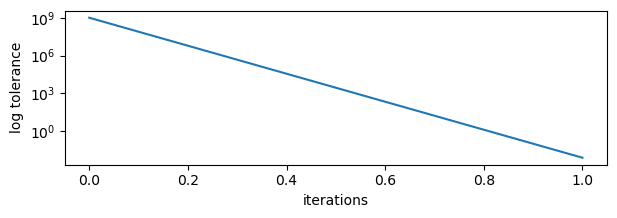

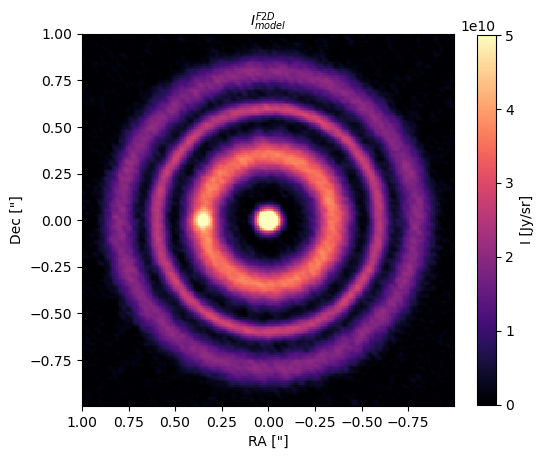

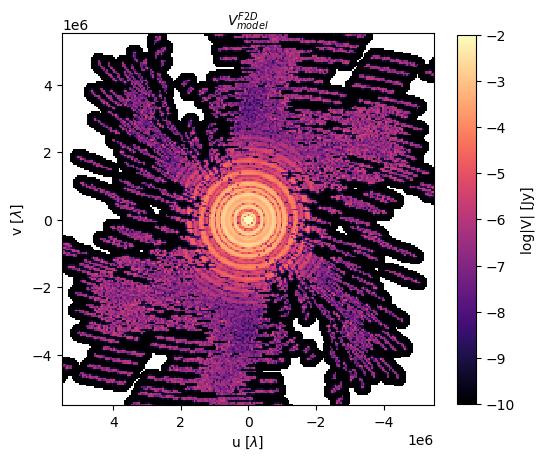

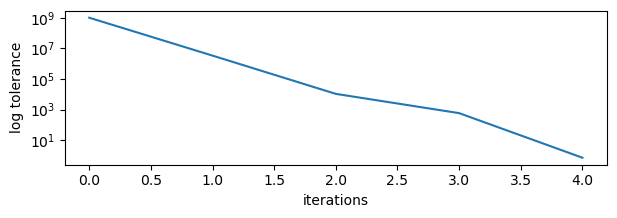

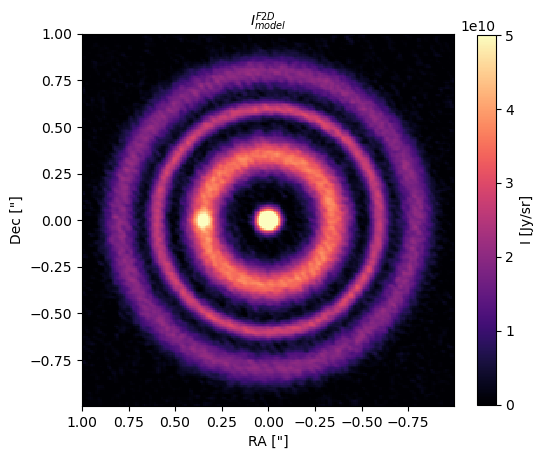

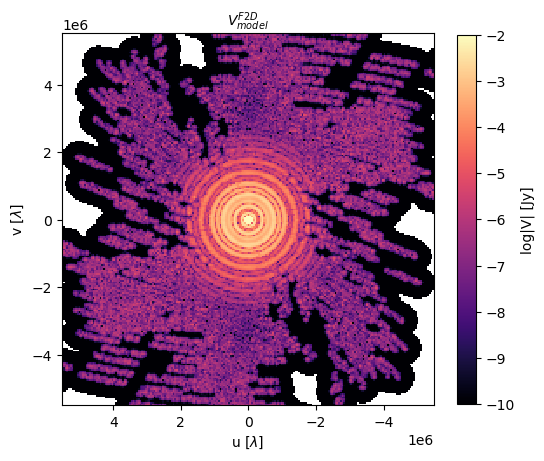

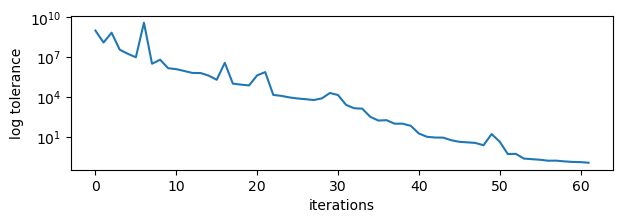

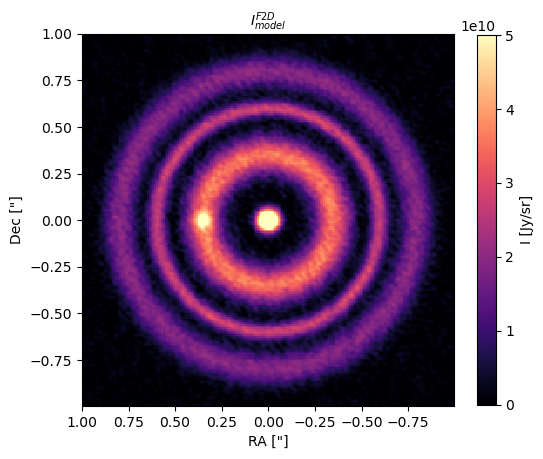

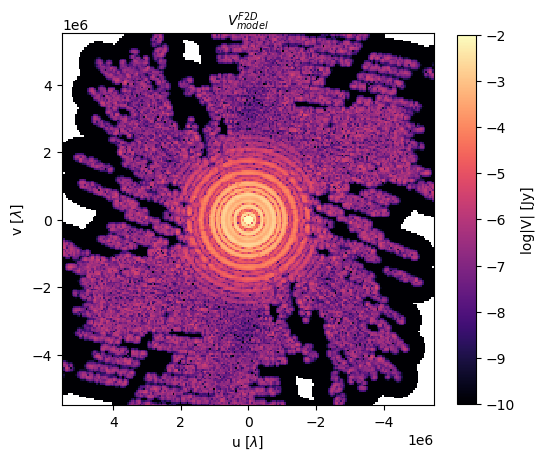

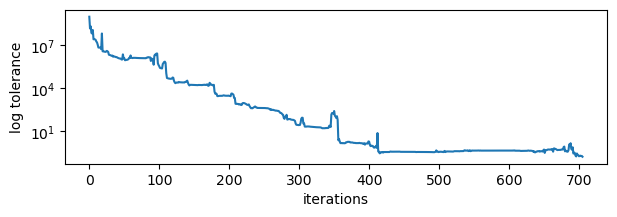

In [32]:
for i in frank2d_objects_se:
    Plot_se = Plot(i, geom)
    Plot_se.intensity(vmax=5e10, gamma = 1, zoom = 2, title = r'$I_{model}^{F2D}$')
    Plot_se.visibility(fig_size = 6, zoom =2)
    Plot_se.cg_tolerance()

In [55]:
len(frank2d_objects_se)

4

In [56]:
l

[10000.0, 20000.0, 40000.0, 50000.0, 70600.20854903864, 80000.0, 90000.0]

In [57]:
times_se.append(648000)

In [62]:
custom_ticks = [10000.0, 20000.0, 40000.0, 50000.0, 70600.20854903864, 90000.0]

custom_labels = [f"{x:.0e}" for x in custom_ticks] 

In [63]:
len(times_se)

5

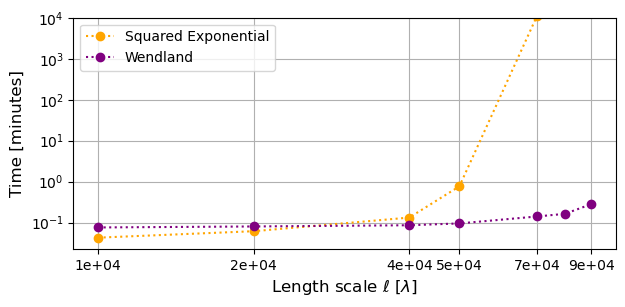

In [70]:
# plot times
plt.figure(figsize=(7,3))
plt.plot(l[:5], np.array(times_se)/60, marker='o', ls=':', c = 'orange', label='Squared Exponential')
plt.plot(l, np.array(times_wend)/60, marker='o', ls=':', color= 'purple', label='Wendland')
plt.xscale('log')
plt.yscale('log')
plt.xticks(custom_ticks, custom_labels)
plt.minorticks_off()
plt.ylim(0, 1e4)
#plt.yscale('log')
plt.xlabel(r'Length scale $\ell$ $[\lambda]$' , size =12)
plt.ylabel( 'Time [minutes]', size =12)
plt.grid()
plt.legend()
plt.show()

In [123]:
len(times_wend)

6